In [161]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
from tensorflow import keras
from tensorflow.keras import layers, models, applications
from tensorflow.keras.applications.vgg16 import preprocess_input
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
# --- ПРОВЕРКА GPU ---
print("Проверка видеокарты...")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Настройка, чтобы TF не забирал сразу всю память, а рос по мере необходимости
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Найдено GPU: {gpus}")
    except RuntimeError as e:
        print(e)
else:
    print("GPU не найден! Будет использован процессор (это медленно).")

Проверка видеокарты...
Найдено GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [162]:
# 1. Настройка путей
path = "C:/Users/Nikita/.cache/kagglehub/datasets/michelheusser/handwritten-digits-and-operators/versions/9" # Укажите здесь путь к вашей папке
print("Изначальный путь к датасету:", path)

# Автоматический поиск папки с данными
dataset_dir = path
while True:
    if not os.path.isdir(dataset_dir):
        break
    items = os.listdir(dataset_dir)
    dirs = [d for d in items if os.path.isdir(os.path.join(dataset_dir, d)) and not d.startswith('.')]
    if len(dirs) == 1:
        dataset_dir = os.path.join(dataset_dir, dirs[0])
    else:
        break

print("Рабочая папка с датасетом:", dataset_dir)

# 2. Параметры загрузки
MAX_IMAGES_PER_CLASS = 1000 

data = []
classes = [d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))]
classes.sort()

for class_name in classes:
    class_path = os.path.join(dataset_dir, class_name)
    
    count = 0
    
    files = os.listdir(class_path)
    
    for img_name in files:
        if count >= MAX_IMAGES_PER_CLASS:
            break
            
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            data.append({
                'path': os.path.join(class_path, img_name),
                'class': class_name
            })
            count += 1

df = pd.DataFrame(data)

if not df.empty:
    print(f"Всего загружено изображений: {len(df)}")
    print("Количество изображений по классам:")
    print(df['class'].value_counts().sort_index())

    # 3. Разделение на обучение и тест
    # stratify, чтобы в тесте и трейне было равное соотношение классов
    train_df, test_df = train_test_split(
        df, 
        test_size=0.2, 
        random_state=42, 
        stratify=df['class']
    )
    print(f"\nРазделение завершено успешно!")
    print(f"Обучающая выборка: {len(train_df)}")
    print(f"Тестовая выборка: {len(test_df)}")
else:
    print("!!! ОШИБКА: Изображения не найдены. Проверьте путь:", dataset_dir)
    
# Вспомогательная функция для рисования графиков обучения
def plot_history(history, title="Training History"):
    plt.figure(figsize=(12, 4))
    
    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Эпохи')
    plt.legend()
    
    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Эпохи')
    plt.legend()
    plt.show()

Изначальный путь к датасету: C:/Users/Nikita/.cache/kagglehub/datasets/michelheusser/handwritten-digits-and-operators/versions/9
Рабочая папка с датасетом: C:/Users/Nikita/.cache/kagglehub/datasets/michelheusser/handwritten-digits-and-operators/versions/9\CompleteImages\All data (Compressed)
Всего загружено изображений: 10000
Количество изображений по классам:
class
0    1000
1    1000
2    1000
3    1000
4    1000
5    1000
6    1000
7    1000
8    1000
9    1000
Name: count, dtype: int64

Разделение завершено успешно!
Обучающая выборка: 8000
Тестовая выборка: 2000


# БЛОК 2: Задание 1 - Аугментация данных (6 вариантов)


Found 8000 validated image filenames belonging to 10 classes.
Found 2000 validated image filenames belonging to 10 classes.


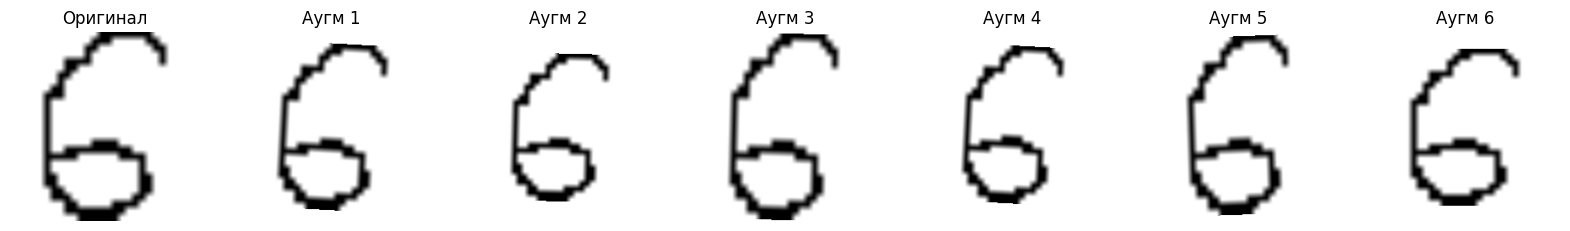

In [189]:
IMG_SIZE = (224, 224) 
BATCH_SIZE = 32
results_log = pd.DataFrame(columns=['Model', 'Loss', 'Accuracy'])

datagen_6 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=5,       
    width_shift_range=0.01,  
    height_shift_range=0.01, 
    zoom_range=[1.0, 1.3],   
    shear_range=0.1,         
    fill_mode='constant',    
    cval=255                 
)

datagen_test = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_6 = datagen_6.flow_from_dataframe(
    train_df, x_col='path', y_col='class',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

test_generator = datagen_test.flow_from_dataframe(
    test_df, x_col='path', y_col='class',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

num_classes = len(train_generator_6.class_indices)

# --- 2. ВИЗУАЛИЗАЦИЯ (БЕЗ preprocess_input) ---

datagen_vis = ImageDataGenerator(
    rotation_range=5,       
    width_shift_range=0.01,  
    height_shift_range=0.01, 
    zoom_range=[1, 1.3],   
    shear_range=0.1,         
    fill_mode='constant',    
    cval=255                 
)

sample_image_path = train_df['path'].iloc[1237]
sample_image = cv2.imread(sample_image_path)
sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)
sample_image_resized = cv2.resize(sample_image, IMG_SIZE)

img_array = np.expand_dims(sample_image_resized, axis=0) 

fig, axes = plt.subplots(1, 7, figsize=(20, 5))
axes[0].imshow(sample_image_resized)
axes[0].set_title('Оригинал')
axes[0].axis('off')

aug_iter = datagen_vis.flow(img_array, batch_size=1)

for i in range(1, 7):
    aug_img = next(aug_iter)[0].astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Аугм {i}')
    axes[i].axis('off')
plt.show()

# БЛОК 3: Загрузка и дообучение VGG16

Создаем модель VGG16...
Model: "sequential_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d_16  (None, 512)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_32 (Dense)            (None, 128)               65664     
                                                                 
 dropout_16 (Dropout)        (None, 128)               0         
                                                                 
 dense_33 (Dense)            (None, 10)                1290      
                                                                 
Total params: 14,781,642
Trainable params: 66,954
Non-trainable params: 14,714,688
____________

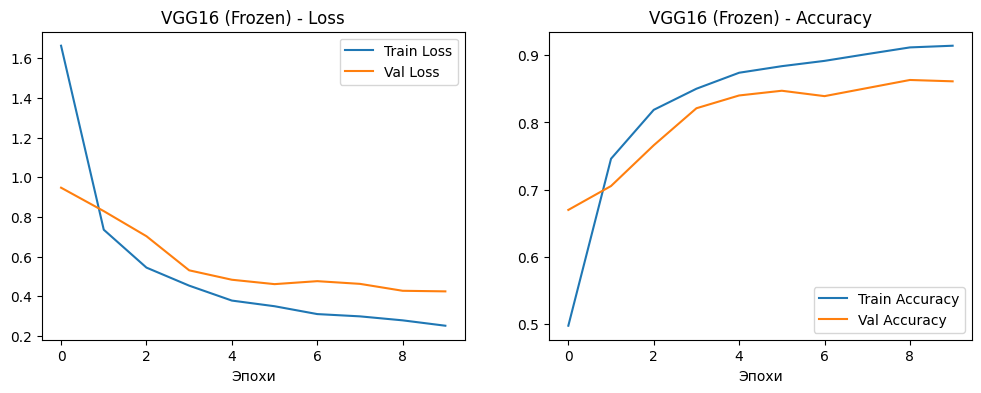


=== Предсказание на 3 тестовых и 3 сторонних изображениях ===
1/1 [==============================] - 0s 17ms/step


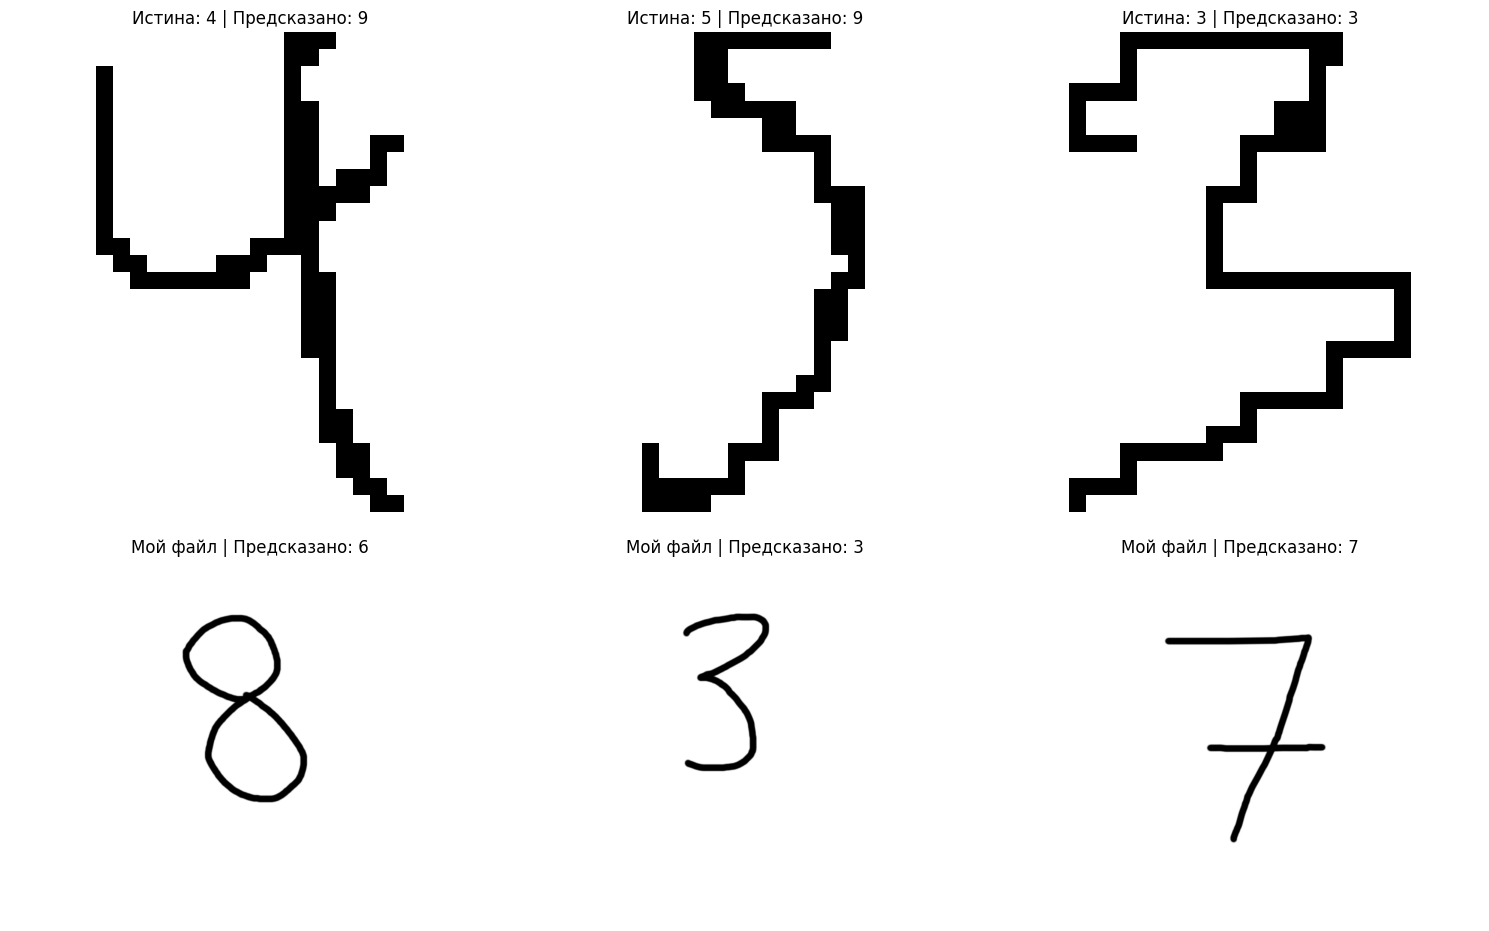

In [192]:
def build_model(base_model, num_classes):
    base_model.trainable = False 
    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(), 
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5), 
        layers.Dense(num_classes, activation='softmax') 
    ])
    model.compile(optimizer= keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

print("Создаем модель VGG16...")
vgg16_base = applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model_vgg16 = build_model(vgg16_base, num_classes)
model_vgg16.summary()

# Обучение 
epochs = 10
history_vgg16 = model_vgg16.fit(train_generator_6, validation_data=test_generator, epochs=epochs)

loss, acc = model_vgg16.evaluate(test_generator)
results_log.loc[len(results_log)] = ['VGG16 (Frozen, 6 Aug)', loss, acc]

plot_history(history_vgg16, "VGG16 (Frozen)")

# === Задание 1.3: Полотно 2x3 (3 из теста, 3 сторонних) ===
print("\n=== Предсказание на 3 тестовых и 3 сторонних изображениях ===")

my_files = [
    'eight.png', 
    'three.png',
    'seven.png'
]

test_samples = test_df.head(3) # Берем 3 картинки из теста
class_labels = list(train_generator_6.class_indices.keys())

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Верхний ряд 3 картинки из тестовой выборки
for i, (_, row) in enumerate(test_samples.iterrows()):
    img = cv2.imread(row['path'])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, IMG_SIZE)
    
    pred = model_vgg16.predict(np.expand_dims(img_resized, axis=0))
    pred_class = class_labels[np.argmax(pred)]
    
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(f"Истина: {row['class']} | Предсказано: {pred_class}")
    axes[0, i].axis('off')

# Нижний ряд 3 моих файла
for i, img_path in enumerate(my_files):
    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, IMG_SIZE)
        
        pred = model_vgg16.predict(np.expand_dims(img_resized, axis=0))
        pred_class = class_labels[np.argmax(pred)]
        
        axes[1, i].imshow(img_rgb)
        axes[1, i].set_title(f"Мой файл | Предсказано: {pred_class}")
    else:
        axes[1, i].text(0.5, 0.5, 'Файл не найден', ha='center', fontsize=12)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# БЛОК 4: Задание 2 - VGG19

Создаем модель VGG19...
Model: "sequential_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 7, 7, 512)         20024384  
                                                                 
 global_average_pooling2d_17  (None, 512)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_34 (Dense)            (None, 128)               65664     
                                                                 
 dropout_17 (Dropout)        (None, 128)               0         
                                                                 
 dense_35 (Dense)            (None, 10)                1290      
                                                                 
Total params: 20,091,338
Trainable params: 66,954
Non-trainable params: 20,024,384
____________

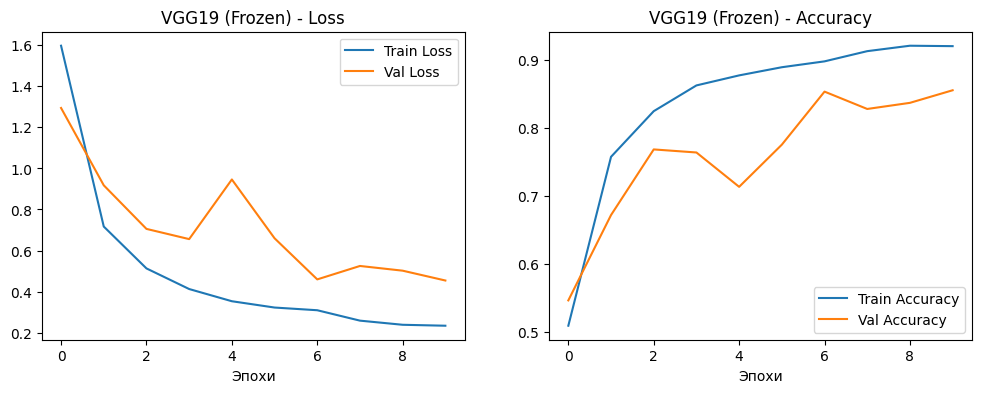

In [193]:
print("Создаем модель VGG19...")
vgg19_base = applications.VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model_vgg19 = build_model(vgg19_base, num_classes)
model_vgg19.summary()

history_vgg19 = model_vgg19.fit(train_generator_6, validation_data=test_generator, epochs=epochs)

loss, acc = model_vgg19.evaluate(test_generator)
results_log.loc[len(results_log)] = ['VGG19 (Frozen, 6 Aug)', loss, acc]

plot_history(history_vgg19, "VGG19 (Frozen)")

# БЛОК 5: Задание 3 - Малая аугментация (2 варианта)

Found 8000 validated image filenames belonging to 10 classes.


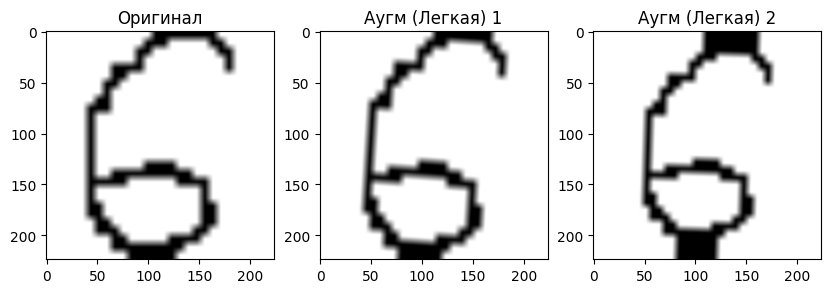

Обучаем VGG16 на датасете с 2 аугментациями...
Epoch 1/10
250/250 [==============================] - 78s 308ms/step - loss: 1.9077 - accuracy: 0.4489 - val_loss: 1.0969 - val_accuracy: 0.6915
Epoch 2/10
250/250 [==============================] - 77s 306ms/step - loss: 0.8750 - accuracy: 0.7023 - val_loss: 0.8380 - val_accuracy: 0.7375
Epoch 3/10
250/250 [==============================] - 76s 302ms/step - loss: 0.6482 - accuracy: 0.7791 - val_loss: 0.6651 - val_accuracy: 0.8075
Epoch 4/10
250/250 [==============================] - 75s 300ms/step - loss: 0.5268 - accuracy: 0.8228 - val_loss: 0.5970 - val_accuracy: 0.8215
Epoch 5/10
250/250 [==============================] - 76s 302ms/step - loss: 0.4484 - accuracy: 0.8435 - val_loss: 0.5530 - val_accuracy: 0.8220
Epoch 6/10
250/250 [==============================] - 78s 312ms/step - loss: 0.3900 - accuracy: 0.8620 - val_loss: 0.5000 - val_accuracy: 0.8370
Epoch 7/10
250/250 [==============================] - 75s 300ms/step - loss: 0.3491

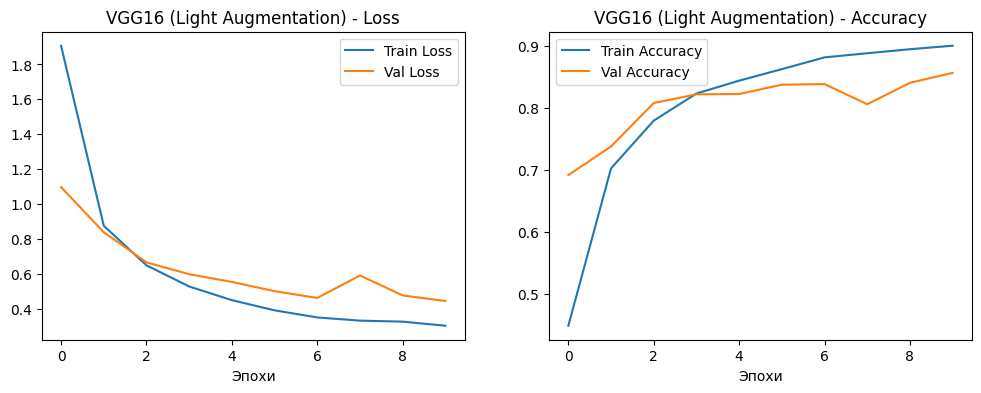

In [194]:
datagen_2 = ImageDataGenerator(
    rotation_range=5,
    zoom_range=[1, 1.3]
)

train_generator_2 = datagen_2.flow_from_dataframe(
    train_df, x_col="path", y_col='class',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

# Визуализация 2 аугментаций
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(sample_image_resized)
axes[0].set_title('Оригинал')

aug_iter_2 = datagen_2.flow(img_array, batch_size=1)
for i in range(1, 3):
    aug_img = next(aug_iter_2)[0].astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Аугм (Легкая) {i}')
plt.show()

# Переобучаем VGG16 на легкой аугментации
print("Обучаем VGG16 на датасете с 2 аугментациями...")
vgg16_base_light = applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model_vgg16_light = build_model(vgg16_base_light, num_classes)

history_vgg16_light = model_vgg16_light.fit(train_generator_2, validation_data=test_generator, epochs=epochs)

loss, acc = model_vgg16_light.evaluate(test_generator)
results_log.loc[len(results_log)] = ['VGG16 (Frozen, 2 Aug)', loss, acc]

plot_history(history_vgg16_light, "VGG16 (Light Augmentation)")

# БЛОК 6: Задание 4 - Разморозка 4 слоев VGG16

Model: "sequential_19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d_19  (None, 512)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_38 (Dense)            (None, 128)               65664     
                                                                 
 dropout_19 (Dropout)        (None, 128)               0         
                                                                 
 dense_39 (Dense)            (None, 10)                1290      
                                                                 
Total params: 14,781,642
Trainable params: 7,146,378
Non-trainable params: 7,635,264
__________________________________

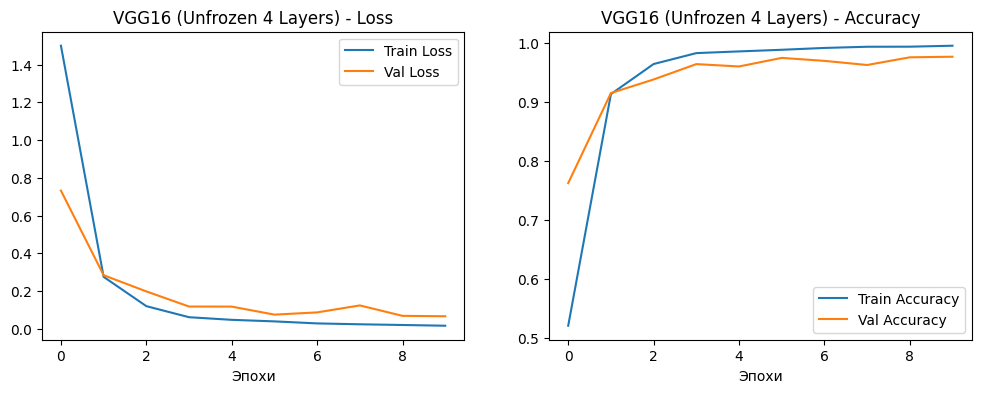

In [195]:
vgg16_base_unfrozen = applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Размораживаем всю базовую модель
vgg16_base_unfrozen.trainable = True

# Проходимся по слоям и замораживаем все, КРОМЕ последних 4
for layer in vgg16_base_unfrozen.layers[:-4]:
    layer.trainable = False

# Собираем классификатор
model_vgg16_unfrozen = keras.Sequential([
    vgg16_base_unfrozen,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

model_vgg16_unfrozen.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5), 
                             loss='categorical_crossentropy', metrics=['accuracy'])

model_vgg16_unfrozen.summary()

history_vgg16_unfrozen = model_vgg16_unfrozen.fit(train_generator_6, validation_data=test_generator, epochs=epochs)

loss, acc = model_vgg16_unfrozen.evaluate(test_generator)
results_log.loc[len(results_log)] = ['VGG16 (Unfrozen 4, 6 Aug)', loss, acc]

plot_history(history_vgg16_unfrozen, "VGG16 (Unfrozen 4 Layers)")

# БЛОК 7: Задание 5 - MobileNetV2 и ResNet50

Создаем MobileNetV2...
Epoch 1/10
250/250 [==============================] - 61s 235ms/step - loss: 1.0086 - accuracy: 0.6528 - val_loss: 0.7611 - val_accuracy: 0.7470
Epoch 2/10
250/250 [==============================] - 59s 237ms/step - loss: 0.4681 - accuracy: 0.8518 - val_loss: 0.4903 - val_accuracy: 0.8510
Epoch 3/10
250/250 [==============================] - 59s 236ms/step - loss: 0.3556 - accuracy: 0.8816 - val_loss: 0.5726 - val_accuracy: 0.8110
Epoch 4/10
250/250 [==============================] - 58s 232ms/step - loss: 0.3026 - accuracy: 0.8971 - val_loss: 0.3953 - val_accuracy: 0.8730
Epoch 5/10
250/250 [==============================] - 58s 232ms/step - loss: 0.2544 - accuracy: 0.9171 - val_loss: 0.3732 - val_accuracy: 0.8795
Epoch 6/10
250/250 [==============================] - 58s 232ms/step - loss: 0.2351 - accuracy: 0.9198 - val_loss: 0.3463 - val_accuracy: 0.8960
Epoch 7/10
250/250 [==============================] - 58s 231ms/step - loss: 0.2209 - accuracy: 0.9229 - va

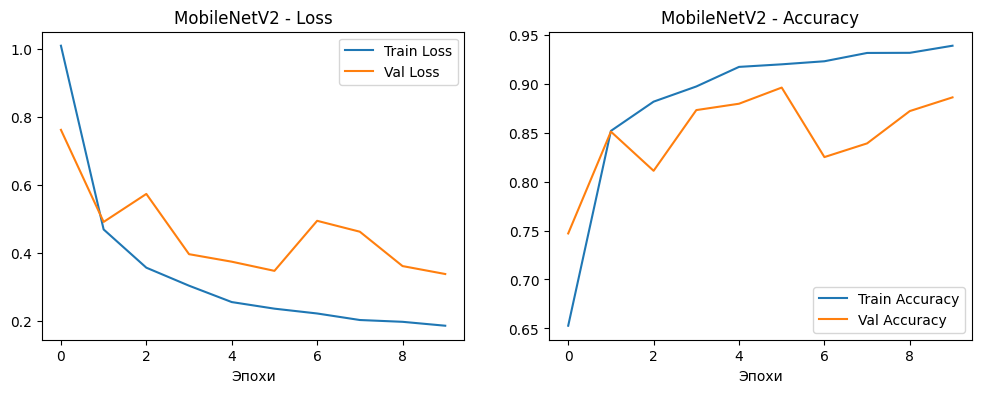

Создаем ResNet50...
Epoch 1/10
250/250 [==============================] - 66s 251ms/step - loss: 1.2656 - accuracy: 0.5580 - val_loss: 1.0069 - val_accuracy: 0.7100
Epoch 2/10
250/250 [==============================] - 64s 254ms/step - loss: 0.7234 - accuracy: 0.7536 - val_loss: 0.7799 - val_accuracy: 0.7890
Epoch 3/10
250/250 [==============================] - 66s 265ms/step - loss: 0.5564 - accuracy: 0.8129 - val_loss: 0.6233 - val_accuracy: 0.8205
Epoch 4/10
250/250 [==============================] - 65s 259ms/step - loss: 0.4748 - accuracy: 0.8389 - val_loss: 0.6182 - val_accuracy: 0.8095
Epoch 5/10
250/250 [==============================] - 65s 259ms/step - loss: 0.4271 - accuracy: 0.8581 - val_loss: 0.6176 - val_accuracy: 0.7985
Epoch 6/10
250/250 [==============================] - 67s 268ms/step - loss: 0.3712 - accuracy: 0.8763 - val_loss: 0.5205 - val_accuracy: 0.8255
Epoch 7/10
250/250 [==============================] - 65s 258ms/step - loss: 0.3600 - accuracy: 0.8779 - val_l

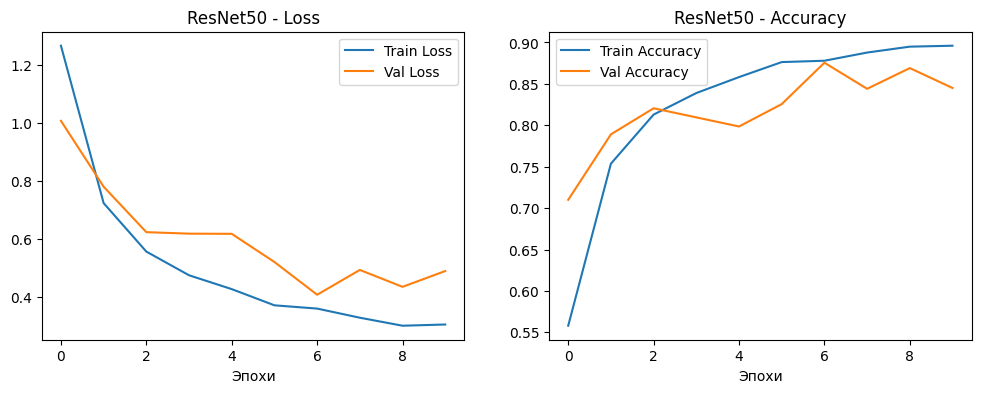


=== ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ===
                    Model     Loss  Accuracy
    VGG16 (Frozen, 6 Aug) 0.424049    0.8610
    VGG19 (Frozen, 6 Aug) 0.454266    0.8555
    VGG16 (Frozen, 2 Aug) 0.443415    0.8560
VGG16 (Unfrozen 4, 6 Aug) 0.066655    0.9765
     MobileNetV2 (Frozen) 0.336985    0.8860
        ResNet50 (Frozen) 0.489328    0.8450


In [196]:
# БЛОК 7: Задание 5 - Другие модели
# 1. MobileNetV2 - легкая и быстрая модель
print("Создаем MobileNetV2...")
mobilenet_base = applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model_mobile = build_model(mobilenet_base, num_classes)

history_mobile = model_mobile.fit(train_generator_6, validation_data=test_generator, epochs=epochs)
loss, acc = model_mobile.evaluate(test_generator)
results_log.loc[len(results_log)] = ['MobileNetV2 (Frozen)', loss, acc]
plot_history(history_mobile, "MobileNetV2")

# 2. ResNet50 - модель с residual-блоками
print("Создаем ResNet50...")
resnet_base = applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model_resnet = build_model(resnet_base, num_classes)

history_resnet = model_resnet.fit(train_generator_6, validation_data=test_generator, epochs=epochs)
loss, acc = model_resnet.evaluate(test_generator)
results_log.loc[len(results_log)] = ['ResNet50 (Frozen)', loss, acc]
plot_history(history_resnet, "ResNet50")

# Выводим финальный лог сравнения всех моделей
print("\n=== ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ===")
print(results_log.to_string(index=False))

# БЛОК 8: Матрица ошибок и тест на собственных изображениях

63/63 [==============================] - 12s 190ms/step


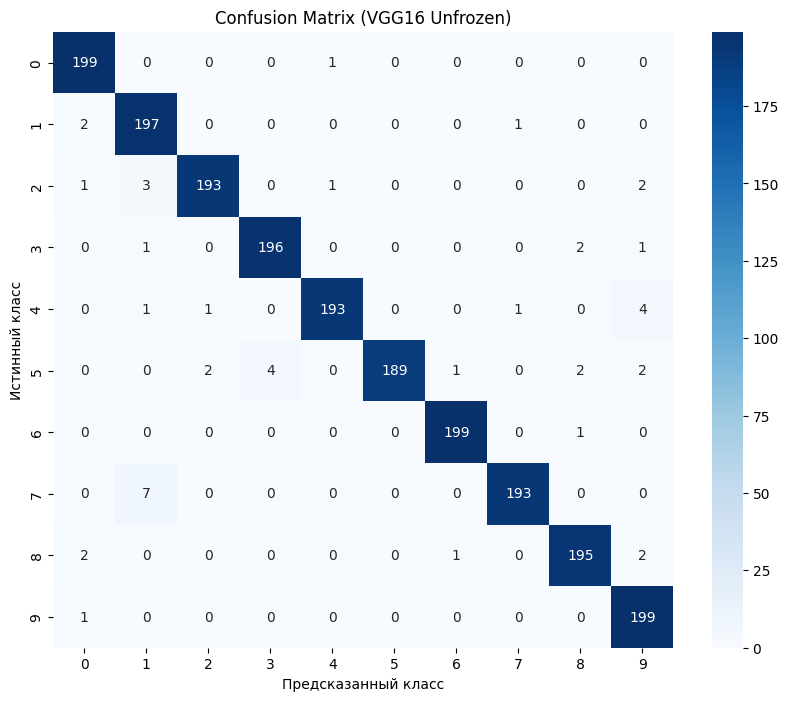

1/1 [==============================] - 0s 208ms/step


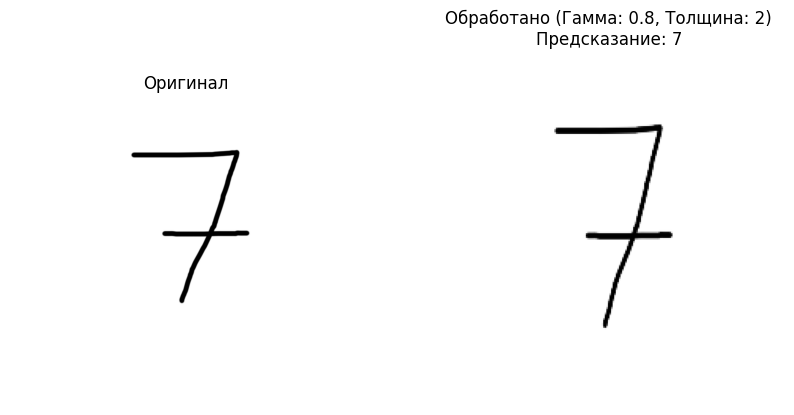

1/1 [==============================] - 0s 204ms/step


In [198]:
# 1. Построение Confusion Matrix для model_vgg16_unfrozen
Y_pred = model_vgg16_unfrozen.predict(test_generator)
y_pred_classes = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix (VGG16 Unfrozen)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

# 2. Обработка своего изображения с настройкой гаммы и толщины
def predict_custom_image(model, img_path, class_labels, gamma=1.0, thickness=1):
    # Загружаем черно-белое для обработки
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Файл не найден. Укажи правильный путь!")
        return

    # Настройка гаммы
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    img_gamma = cv2.LUT(img, table)

    kernel = np.ones((thickness, thickness), np.uint8)
   
    img_processed = cv2.dilate(img_gamma, kernel, iterations=1) 

    img_color = cv2.cvtColor(img_processed, cv2.COLOR_GRAY2RGB)
    img_resized = cv2.resize(img_color, IMG_SIZE)
    img_array = np.expand_dims(img_resized, axis=0)

    prediction = model.predict(img_array)
    predicted_class = class_labels[np.argmax(prediction)]

    orig_img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(orig_img)
    axes[0].set_title('Оригинал')
    axes[0].axis('off')
    
    axes[1].imshow(img_resized)
    axes[1].set_title(f'Обработано (Гамма: {gamma}, Толщина: {thickness})\nПредсказание: {predicted_class}')
    axes[1].axis('off')
    plt.show()
    # ===ТЕСТ ===
    img_resized = cv2.resize(orig_img, (224, 224))
    img_array = np.expand_dims(img_resized, axis=0) 
    processed_image = preprocess_input(img_array)
    prediction = model.predict(processed_image)

my_test_image = 'seven.png' 
predict_custom_image(model_vgg16_unfrozen, my_test_image, class_labels, gamma=0.8, thickness=2)